# Investigate RS.PROS_Test.dcm: 
**PTV -> CTV**, <br>
**PTV -> opt Bladder**, <br>
**PTV -> opt Rectum**, <br>

This notebook reproduces the relationship pipeline for the DICOM RT Structure 
Set `RS.PROS_Test.dcm` and documents the per-slice relations that are 
merged into the final relation.

## 1) Load DICOM file and build StructureSet

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from contour_plotting import plot_ab, plot_roi_slice


In [2]:
# Ensure src imports work regardless of notebook working directory
cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'src').exists() and (candidate / 'Tests').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate repository root containing src/ and tests/.')

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dicom import DicomStructureFile
from structure_set import StructureSet
from relations import DE27IM
from region_slice import empty_structure

dicom_path = repo_root / 'Tests' / 'RS.PROS_Test.dcm'
dicom_file = DicomStructureFile(top_dir=repo_root / 'Tests',
                                file_path=dicom_path)
structure_set = StructureSet(
    dicom_structure_file=dicom_file,
    include_structures=['CTV', 'PTV', 'Iliac*', 'Prostate',
                        'Bladder', 'Rectum', 'opt*'],
    exclude_structures=[r'\$.*', r'^Avoid', r'^Z', r'^BOB']
    )

print(f'Loaded: {dicom_path}')
print(f'Structures found: {len(structure_set.structures)}')
print(f'Relationship graph edges: {structure_set.relationship_graph.number_of_edges()}')

INFO:dicom:Successfully loaded DICOM dataset from RS.PROS_Test.dcm
INFO:dicom:Extracted 2446 contours from 22 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.PROS_Test.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.040 cm/pixel
INFO:structure_set:Building StructureSet from 2446 contour points (unit: cm)
INFO:structure_set:Skipping structure BODY (1) due to filters
INFO:structure_set:Skipping structure CouchSurface (3) due to filters
INFO:structure_set:Skipping structure CouchInterior (4) due to filters
INFO:structure_set:Skipping structure $Bowel_Full (11) due to filters
INFO:structure_set:Adding structure CTV (20)
INFO:structure_set:Adding structure Iliac Vessels L (22)
INFO:structure_set:Adding structure Iliac Vessels R (23)
INFO:structure_set:Adding structure PTV (24)
INFO:structure_set:Skipping structure Avoid a Rectum (29) due to filters
INFO:structure_set:Skipping structure Avoid b Rectum (30) due to filters
INFO:structur

Loaded: D:\OneDrive - Queen's University\Python\Projects\StructureRelations\Tests\RS.PROS_Test.dcm
Structures found: 9
Relationship graph edges: 36


## 2. Useful functions

### a) Functions to map target structure names and ROI numbers

In [3]:
ROI_TABLE = pd.DataFrame([
    {'roi': roi, 'name': structure.name}
    for roi, structure in structure_set.structures.items()
]).sort_values('name').reset_index(drop=True)
display(ROI_TABLE)


,roi,name
0,31,Bladder
1,20,CTV
2,22,Iliac Vessels L
3,23,Iliac Vessels R
4,24,PTV
5,38,Prostate
6,39,Rectum
7,45,opt Bladder
8,46,opt Rectum


In [4]:
def find_roi_by_name(target_name: str, table: pd.DataFrame) -> int:
    exact = table.loc[table['name'] == target_name, 'roi']
    if not exact.empty:
        return int(exact.iloc[0])

    normalized = table['name'].str.lower().str.strip()
    target_norm = target_name.lower().strip()

    exact_norm = table.loc[normalized == target_norm, 'roi']
    if not exact_norm.empty:
        return int(exact_norm.iloc[0])

    contains = table.loc[normalized.str.contains(target_norm, regex=False), 'roi']
    if len(contains) == 1:
        return int(contains.iloc[0])

    raise ValueError(
        f'Could not uniquely resolve ROI for {target_name}. '
        'Check roi_table for actual names.'
    )


### b) Function to identify relationships one each slice

In [5]:
def get_slice_relations(structure_a, structure_b):
    # Match StructureShape.relate_to() filtering logic:
    # Only use positions where at least one structure has a non-interpolated
    # (original) or boundary-face slice.
    valid_mask_a = (
        ~structure_a.region_table.Interpolated
        | structure_a.region_table.IsBoundary
    )
    valid_slices_a = set(
        structure_a.region_table.loc[valid_mask_a, 'SliceIndex']
    )

    valid_mask_b = (
        ~structure_b.region_table.Interpolated
        | structure_b.region_table.IsBoundary
    )
    valid_slices_b = set(
        structure_b.region_table.loc[valid_mask_b, 'SliceIndex']
    )

    # Union of valid positions from both structures
    used_slices = valid_slices_a | valid_slices_b

    mask_a = structure_a.region_table.SliceIndex.isin(used_slices) & ~structure_a.region_table.Empty
    mask_b = structure_b.region_table.SliceIndex.isin(used_slices) & ~structure_b.region_table.Empty

    regions_a = structure_a.region_table.loc[mask_a, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions_b = structure_b.region_table.loc[mask_b, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions = regions_a.join(regions_b, how='outer', lsuffix='_a', rsuffix='_b').sort_index()

    cumulative = DE27IM()
    slice_rows = []

    for slice_index, row in regions.iterrows():
        region_a = row['RegionSlice_a']
        region_b = row['RegionSlice_b']

        relation = DE27IM(region_a, region_b, tolerance=structure_set.tolerance)
        relation_type = relation.identify_relation()

        cumulative.merge(relation)
        cumulative_type = cumulative.identify_relation()

        slice_rows.append({
            'slice_index': float(slice_index),
            'a_present': not empty_structure(region_a),
            'b_present': not empty_structure(region_b),
            'slice_relation_type': relation_type.relation_type if relation_type else None,
            'slice_relation_label': relation_type.label if relation_type else None,
            'slice_de27im_bits': relation.relation,
            'slice_de27im_int': relation.int,
            'cumulative_relation_type': cumulative_type.relation_type if cumulative_type else None,
            'cumulative_relation_label': cumulative_type.label if cumulative_type else None,
            'cumulative_de27im_bits': cumulative.relation,
            'cumulative_de27im_int': cumulative.int,
        })

    slice_relation_df = pd.DataFrame(slice_rows).sort_values('slice_index').reset_index(drop=True)
    slice_relation_df.set_index('slice_index', inplace=True)
    return slice_relation_df, cumulative


### c) Functions to plot structures

In [6]:
def plot_slice_ax(ax, slice_idx, structure_a, structure_b, slice_relation_df):
    # Get the RegionSlice objects for both structures at this slice
    region_a = structure_a.get_slice(slice_idx)
    region_b = structure_b.get_slice(slice_idx)

    try:
        plot_ab(region_a, region_b, axes=ax, add_axis=True)
        # Get the relation type for this slice from our dataframe
        slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
        if not slice_rel.empty:
            rel_label = slice_rel.iloc[0]['slice_relation_label']
            ax.set_title(
                f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
                f'Slice relation: {rel_label}',
                fontsize=12
            )
        else:
            ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
    except Exception as err:
        ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(err)}',
            ha='center', va='center')
        ax.set_title(f'z={slice_idx:.2f}')


In [7]:
def plot_single_slice(slice_idx, structure_a, structure_b, slice_relation_df):
    # Create figure and plot
    fig, ax = plt.subplots(figsize=(4, 4))
    try:
        plot_slice_ax(ax, slice_idx, structure_a, structure_b, slice_relation_df)
    except Exception as err:
        ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(err)}',
            ha='center', va='center')
        ax.set_title(f'z={slice_idx:.2f}')

    plt.tight_layout()
    plt.show()

    print('\n🔍 Plot Legend:')
    print('  Blue area: Only in A (PTV Total)')
    print('  Green area: Only in B (GTV 1 xxGy)')
    print('  Orange area: Intersection (both A and B)')
    print('  Gray dashed lines: Origin (X=0, Y=0)')

## 3) Relationship validation table: Expected vs Actual

In [8]:
# Define expected relationships based on clinical/geometric requirements
expected_relations = {
    ('PTV', 'CTV'): 'Contains',
    ('PTV', 'opt Bladder'): 'Borders',
    ('PTV', 'opt Rectum'): 'Borders',
    ('CTV', 'opt Rectum'): 'is Disjoint from',
    ('CTV', 'opt Bladder'): 'is Disjoint from',
    ('Rectum', 'opt Rectum'): 'is Partitioned by',
    ('Bladder', 'opt Bladder'): 'is Partitioned by',
#    ('PTV 1_24Gyin3', 'GTV Total'):     'Overlaps with',

    }


In [9]:
# Collect results
comparison_rows = []
for (name_a, name_b), expected_type in expected_relations.items():
    try:
        roi_a = find_roi_by_name(name_a, ROI_TABLE)
        roi_b = find_roi_by_name(name_b, ROI_TABLE)
    except ValueError as err:
        print(f'Error finding ROI for {name_a} or {name_b}: {err}')
        continue

    rel = structure_set.get_relationship(roi_a, roi_b)
    actual_type = rel.relationship_type.label if rel and rel.relationship_type else 'Unknown'

    is_match = (expected_type == actual_type)

    comparison_rows.append({
        'Structure A': name_a,
        'Structure B': name_b,
        'Expected': expected_type,
        'Actual': actual_type,
        'Match': '✅' if is_match else '❌',
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# Show mismatches
mismatches = comparison_df[comparison_df['Match'] == '❌']
print(f'\n⚠️ INCORRECT RELATIONSHIPS: {len(mismatches)} out of {len(comparison_df)}')
if len(mismatches) > 0:
    display(mismatches[['Structure A', 'Structure B', 'Expected', 'Actual']])

print(f'Default tolerance is {structure_set.tolerance}')

,Structure A,Structure B,Expected,Actual,Match
0,PTV,CTV,Contains,Contains,✅
1,PTV,opt Bladder,Borders,Borders,✅
2,PTV,opt Rectum,Borders,Borders,✅
3,CTV,opt Rectum,is Disjoint from,is Disjoint from,✅
4,CTV,opt Bladder,is Disjoint from,is Disjoint from,✅
5,Rectum,opt Rectum,is Partitioned by,is Partitioned by,✅
6,Bladder,opt Bladder,is Partitioned by,is Partitioned by,✅



⚠️ INCORRECT RELATIONSHIPS: 0 out of 7
Default tolerance is 0.04


## 5) Check on specific relationship:
- PTV Total -> GTV 1 xxGy

In [10]:
target_a_name = 'PTV'
target_b_name = 'CTV'


In [11]:
roi_a = find_roi_by_name(target_a_name, ROI_TABLE)
roi_b = find_roi_by_name(target_b_name, ROI_TABLE)

print(f'{target_a_name} -> ROI {roi_a}')
print(f'{target_b_name} -> ROI {roi_b}')
print('\n')
relationship = structure_set.get_relationship(roi_a, roi_b)

print(f'A: {structure_set.structures[roi_a].name} (ROI {roi_a})')
print(f'B: {structure_set.structures[roi_b].name} (ROI {roi_b})')
print('\n')

print(f'Tolerance used for relation calculations: {structure_set.tolerance}')
print(f'Final relation type: {relationship.relationship_type.label}')
print(f'Final relation type key: {relationship.relationship_type.relation_type}')
print(f'Final DE27IM bits: {relationship.de27im.relation}')
print(f'Final DE27IM int: {relationship.de27im.int}')

structure_a = structure_set.structures[roi_a]
structure_b = structure_set.structures[roi_b]

PTV -> ROI 24
CTV -> ROI 20


A: PTV (ROI 24)
B: CTV (ROI 20)


Tolerance used for relation calculations: 0.04
Final relation type: Contains
Final relation type key: CONTAINS
Final DE27IM bits: 111001001111001001111001001
Final DE27IM int: 120034249


### 5a) Slice-by-slice relations and cumulative merge

This mirrors `StructureShape.relate()`:
- iterate union of non-empty slices for A and B
- compute per-slice `DE27IM(region_a, region_b, tolerance=structure_set.tolerance)`
- merge with bitwise OR into cumulative DE27IM

In [12]:
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

#### Consistency checks

In [13]:
print(f'Tolerance used for relation calculations: {structure_set.tolerance}')
print('StructureSet final relation type:', relationship.relationship_type.relation_type)
print('Reconstructed final relation type:', cumulative.identify_relation().relation_type)
print('\nStructureSet DE27IM:')
print('  Bits:', relationship.de27im.relation)
print('  Int: ', relationship.de27im.int)
print('\nReconstructed DE27IM:')
print('  Bits:', cumulative.relation)
print('  Int: ', cumulative.int)

if relationship.de27im.int != cumulative.int:
    print('\n⚠️ MISMATCH DETECTED!')
    print(f'Difference: {relationship.de27im.int - cumulative.int}')
    # Show bit-by-bit comparison
    ss_bin = bin(relationship.de27im.int)[2:].zfill(27)
    cum_bin = bin(cumulative.int)[2:].zfill(27)
    print('\nBit-by-bit comparison (StructureSet vs Reconstructed):')
    for i in range(0, 27, 9):
        print(f'  Positions {i:2d}-{i+8:2d}: {ss_bin[i:i+9]} vs {cum_bin[i:i+9]}')
else:
    print('\n✅ Reconstructed cumulative relation matches StructureSet output.')


Tolerance used for relation calculations: 0.04
StructureSet final relation type: CONTAINS
Reconstructed final relation type: CONTAINS

StructureSet DE27IM:
  Bits: 111001001111001001111001001
  Int:  120034249

Reconstructed DE27IM:
  Bits: 111001001111001001111001001
  Int:  120034249

✅ Reconstructed cumulative relation matches StructureSet output.


#### Relationships on individual slices where both structures are present

In [14]:
both_present = slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']].copy()
column_selector = ['slice_relation_label', 'cumulative_relation_label', 'slice_de27im_bits', 'cumulative_de27im_bits']
display(both_present[column_selector])


,slice_relation_label,cumulative_relation_label,slice_de27im_bits,cumulative_de27im_bits
slice_index,,,,
-6.1,NaN,NaN,010000000000000000000000000,011001001001001001001001001
-6.0,Contains,Contains,111001001111001001111001001,111001001111001001111001001
-5.8,Contains,Contains,111001001111001001111001001,111001001111001001111001001
-5.6,Contains,Contains,111001001111001001111001001,111001001111001001111001001
-5.4,Contains,Contains,111001001111001001111001001,111001001111001001111001001
...,...,...,...,...
12.0,Contains,Contains,111001001111001001111001001,111001001111001001111001001
12.2,Contains,Contains,111001001111001001111001001,111001001111001001111001001
12.4,Contains,Contains,111001001111001001111001001,111001001111001001111001001


index	relation	DE27IM
-0.05	Overlaps    111001111111001001111001001
-0.10	Contains    111001001111001001111001001

-0.05
Overlaps
111 111 111
001 001 001
111 001 001

-0.10	
Contains    
111 111 111
001 001 001
001 001 001

"relation_type": "CONTAINS",
"label": "Contains",
"pattern": "TT*FF*F**\tT********\tT********",
"mask": "0b110110100100000000100000000",
"value": "0b110000000100000000100000000",


"relation_type": "OVERLAPS",
"label": "Overlaps",
"pattern": "T*****T**\tT********\tT********",
"mask": "0b100000100100000000100000000",
"value": "0b100000100100000000100000000",


### 5b) Visualize contours with plot_ab

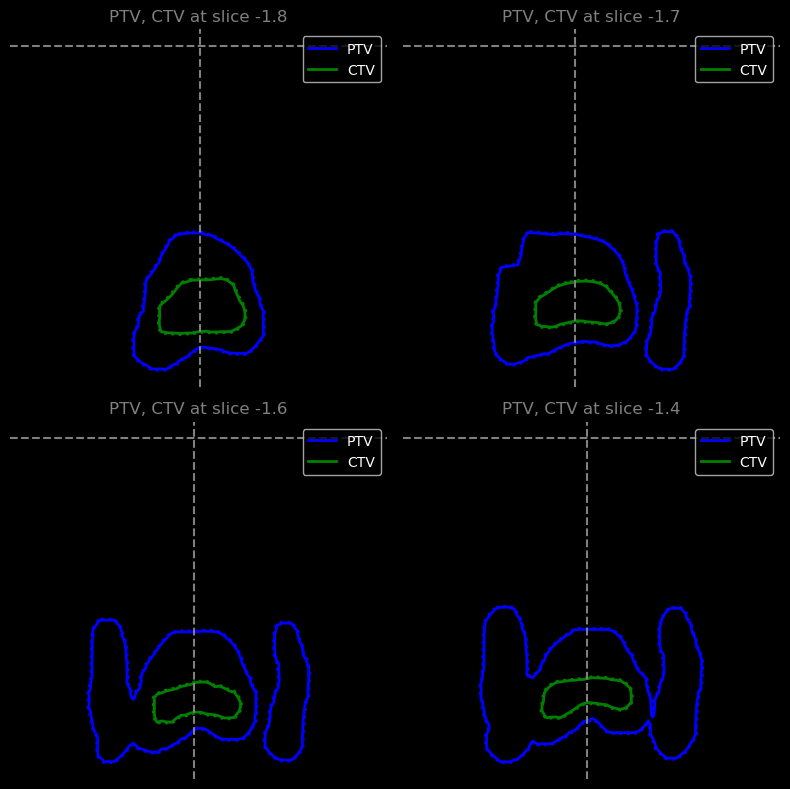


🔍 Plot Legend:
  Blue area: Only in A (PTV)
  Green area: Only in B (CTV)
  Orange area: Intersection (both A and B)
  Gray dashed lines: Origin (X=0, Y=0)


In [15]:
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
slice_idx = -1.8
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[0, 0], tolerance=0.1,
               plot_mode='contour')
#               plot_mode='relationship')
slice_idx = -1.7
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[0, 1], tolerance=0.1,
               plot_mode='contour')
#               plot_mode='relationship')
slice_idx = -1.6
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[1, 0], tolerance=0.1,
               plot_mode='contour')
#               plot_mode='relationship')
slice_idx = -1.4
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[1, 1], tolerance=0.1,
               plot_mode='contour')
#               plot_mode='relationship')

plt.tight_layout()
plt.show()

print('\n🔍 Plot Legend:')
print(f'  Blue area: Only in A ({target_a_name})')
print(f'  Green area: Only in B ({target_b_name})')
print('  Orange area: Intersection (both A and B)')
print('  Gray dashed lines: Origin (X=0, Y=0)')

In [16]:
a = structure_set.slice_sequence.sequence

In [17]:
import pydicom
import numpy as np
ds = pydicom.dcmread(dicom_path)


In [18]:
seq = ds.ROIContourSequence
roi_seq = [item.ReferencedROINumber for item in seq]
#roi_seq

In [19]:
print(roi_a,target_a_name)
print(roi_b,target_b_name)

24 PTV
20 CTV


In [20]:
structure_index = roi_seq.index(roi_b)
structure_item = seq[structure_index]
structure_item.ContourSequence[0]
contour_points = []
for contour in structure_item.ContourSequence:
    points_array = np.array(contour.ContourData).reshape(-1, 3)
    # Convert from mm to cm (DICOM uses mm, our system uses cm)
    points_array = points_array / 10.0
    contour_points.append(points_array)

<Axes: title={'center': 'PTV, CTV at slice -1.6'}>

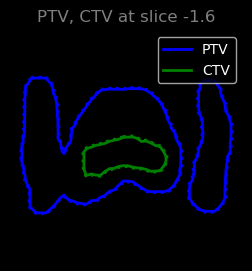

In [21]:
fig, ax = plt.subplots(figsize=(3, 3))
slice_idx = -1.6
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
                   axes=ax, tolerance=0.1)